In [1]:
import torch
import os
from pathlib import Path
import json
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
from sklearn.preprocessing import StandardScaler
import h5py

In [2]:
import logging

logging.basicConfig(
    format='[%(asctime)s] %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S',
    level=logging.DEBUG
)

logger = logging.getLogger()
logger.info("hi")  # Same clean output

[2025-12-09 13:18:33] hi


In [3]:
# Constants
METADATA_PATH = "/home/harinit9/orcd/pool/musicgen-data-nokey/dataset_metadata.json"
ACT_BATCHED_PATH = Path("/home/wyf/orcd/pool/musicgen-activations-nokey/activations_pooled")
ACTS_BY_LAYER_PATH = Path("/home/wyf/orcd/pool/musicgen-activations-nokey/acts_by_layer")

In [4]:
with open(METADATA_PATH) as fin:
    metadata = json.load(fin)

In [20]:
# Define main fitting function based on layer idx

class_labels = ["major", "minor"]

def train_linear_probe(
    layer_idx: int,
    pca_dim: int,
    pooling_strat: str,
):
    acts = np.load(ACTS_BY_LAYER_PATH / f"layer_{layer_idx:02d}.npy")
    logger.info(f"Logistic regression on {layer_idx=}")

    # Pool across time
    logger.info("Pooling...")
    if pooling_strat == "max":
        X_pooled = np.max(acts, axis=1)
    else:
        X_pooled = np.mean(acts, axis=1)

    # Normalize per feature
    logger.info("Normalizing...")
    # X_norm = StandardScaler().fit_transform(X_pooled)

    # Run PCA to reduce dimensionality
    from sklearn.decomposition import PCA

    logger.info("Running pca...")
    pca = PCA(n_components=pca_dim)
    X_pca = pca.fit_transform(X_pooled)     # shape: (1000, pca_dim)
    y_raw = np.array([
        class_labels.index(clip["key_info"]["mode"])
        for clip in metadata
    ])

    # Make train/test splits
    logger.info("Making test splits...")

    for _ in range(1024):
        from sklearn.model_selection import train_test_split
        X_train, X_test, y_train, y_test = train_test_split(
            X_pca, y_raw,
            test_size=0.3,
            stratify=y_raw,
        )

        # Run logistic regression
        from sklearn.linear_model import LogisticRegression

        # logger.info("Fitting logistic regression...")
        reg = LogisticRegression()
        reg.fit(X_train, y_train)

        # Plot confusion matrix
        from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

        def evaluate(X, y):
            y_pred = reg.predict(X) >= 0.5

            cm = confusion_matrix(y, y_pred)
            # disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
            # disp.plot()
            
            acc = accuracy_score(y, y_pred)
            return cm, acc
        
        # logger.info("Running eval...")
        _, train_acc = evaluate(X_train, y_train)
        _, test_acc = evaluate(X_test, y_test)

        print(f"[{layer_idx=}]  train_acc={train_acc * 100:.3f}%, test_acc={test_acc * 100:.3f}")
        yield train_acc, test_acc

In [21]:
records = []

In [22]:
# logger.setLevel("ERROR")
logger.setLevel("DEBUG")

# Runs in 2m
for layer_idx in range(48):
    accs = list(train_linear_probe(layer_idx, 128, "max"))
    records.append((layer_idx, accs))

[2025-12-09 02:51:44] Logistic regression on layer_idx=0
[2025-12-09 02:51:44] Pooling...
[2025-12-09 02:51:44] Normalizing...
[2025-12-09 02:51:44] Running pca...
[2025-12-09 02:51:45] Making test splits...


[layer_idx=0]  train_acc=71.143%, test_acc=59.000
[layer_idx=0]  train_acc=73.000%, test_acc=54.000
[layer_idx=0]  train_acc=70.571%, test_acc=56.667
[layer_idx=0]  train_acc=71.571%, test_acc=57.000
[layer_idx=0]  train_acc=68.857%, test_acc=57.667
[layer_idx=0]  train_acc=70.714%, test_acc=53.667
[layer_idx=0]  train_acc=70.571%, test_acc=54.333
[layer_idx=0]  train_acc=72.714%, test_acc=52.000
[layer_idx=0]  train_acc=70.714%, test_acc=58.333
[layer_idx=0]  train_acc=70.571%, test_acc=58.000
[layer_idx=0]  train_acc=69.000%, test_acc=57.667
[layer_idx=0]  train_acc=69.286%, test_acc=57.333
[layer_idx=0]  train_acc=69.857%, test_acc=56.333
[layer_idx=0]  train_acc=71.000%, test_acc=56.333
[layer_idx=0]  train_acc=71.143%, test_acc=57.667
[layer_idx=0]  train_acc=70.429%, test_acc=58.000
[layer_idx=0]  train_acc=69.571%, test_acc=55.333
[layer_idx=0]  train_acc=70.286%, test_acc=54.667
[layer_idx=0]  train_acc=71.286%, test_acc=55.333
[layer_idx=0]  train_acc=71.714%, test_acc=59.667


[2025-12-09 02:51:52] Logistic regression on layer_idx=1
[2025-12-09 02:51:52] Pooling...
[2025-12-09 02:51:52] Normalizing...
[2025-12-09 02:51:52] Running pca...
[2025-12-09 02:51:53] Making test splits...


[layer_idx=1]  train_acc=72.000%, test_acc=54.667
[layer_idx=1]  train_acc=73.000%, test_acc=56.333
[layer_idx=1]  train_acc=71.286%, test_acc=59.333
[layer_idx=1]  train_acc=69.571%, test_acc=57.667
[layer_idx=1]  train_acc=70.714%, test_acc=59.333
[layer_idx=1]  train_acc=71.714%, test_acc=56.667
[layer_idx=1]  train_acc=73.143%, test_acc=55.667
[layer_idx=1]  train_acc=71.857%, test_acc=54.333
[layer_idx=1]  train_acc=71.286%, test_acc=55.000
[layer_idx=1]  train_acc=70.429%, test_acc=54.333
[layer_idx=1]  train_acc=70.143%, test_acc=56.333
[layer_idx=1]  train_acc=70.143%, test_acc=57.333
[layer_idx=1]  train_acc=70.429%, test_acc=54.333
[layer_idx=1]  train_acc=71.143%, test_acc=55.667
[layer_idx=1]  train_acc=71.857%, test_acc=51.000
[layer_idx=1]  train_acc=72.429%, test_acc=56.333
[layer_idx=1]  train_acc=70.714%, test_acc=54.667
[layer_idx=1]  train_acc=69.857%, test_acc=55.667
[layer_idx=1]  train_acc=72.286%, test_acc=55.667
[layer_idx=1]  train_acc=71.143%, test_acc=56.333


[2025-12-09 02:52:01] Logistic regression on layer_idx=2
[2025-12-09 02:52:01] Pooling...
[2025-12-09 02:52:01] Normalizing...
[2025-12-09 02:52:01] Running pca...
[2025-12-09 02:52:02] Making test splits...


...

[layer_idx=45]  train_acc=71.143%, test_acc=59.000
[layer_idx=45]  train_acc=71.000%, test_acc=53.333
[layer_idx=45]  train_acc=71.143%, test_acc=52.667
[layer_idx=45]  train_acc=68.429%, test_acc=59.000
[layer_idx=45]  train_acc=71.286%, test_acc=55.667
[layer_idx=45]  train_acc=72.571%, test_acc=54.667
[layer_idx=45]  train_acc=72.571%, test_acc=54.000
[layer_idx=45]  train_acc=70.286%, test_acc=62.667
[layer_idx=45]  train_acc=73.429%, test_acc=52.333
[layer_idx=45]  train_acc=71.857%, test_acc=56.000
[layer_idx=45]  train_acc=71.143%, test_acc=55.333
[layer_idx=45]  train_acc=71.714%, test_acc=57.000
[layer_idx=45]  train_acc=72.857%, test_acc=57.333
[layer_idx=45]  train_acc=72.286%, test_acc=56.000
[layer_idx=45]  train_acc=71.143%, test_acc=55.667
[layer_idx=45]  train_acc=70.571%, test_acc=58.333
[layer_idx=45]  train_acc=71.286%, test_acc=58.667
[layer_idx=45]  train_acc=73.000%, test_acc=56.333
[layer_idx=45]  train_acc=71.571%, test_acc=54.333
[layer_idx=45]  train_acc=74.14

[2025-12-09 03:01:23] Logistic regression on layer_idx=46
[2025-12-09 03:01:23] Pooling...
[2025-12-09 03:01:26] Normalizing...
[2025-12-09 03:01:26] Running pca...
[2025-12-09 03:01:26] Making test splits...


[layer_idx=46]  train_acc=73.143%, test_acc=54.333
[layer_idx=46]  train_acc=73.857%, test_acc=55.667
[layer_idx=46]  train_acc=71.857%, test_acc=56.333
[layer_idx=46]  train_acc=72.571%, test_acc=56.667
[layer_idx=46]  train_acc=73.571%, test_acc=58.333
[layer_idx=46]  train_acc=69.714%, test_acc=59.333
[layer_idx=46]  train_acc=70.143%, test_acc=58.000
[layer_idx=46]  train_acc=71.714%, test_acc=54.667
[layer_idx=46]  train_acc=69.571%, test_acc=56.000
[layer_idx=46]  train_acc=70.571%, test_acc=57.000
[layer_idx=46]  train_acc=73.286%, test_acc=52.667
[layer_idx=46]  train_acc=68.571%, test_acc=61.667
[layer_idx=46]  train_acc=73.571%, test_acc=55.333
[layer_idx=46]  train_acc=71.714%, test_acc=55.333
[layer_idx=46]  train_acc=70.429%, test_acc=55.000
[layer_idx=46]  train_acc=70.714%, test_acc=57.667
[layer_idx=46]  train_acc=69.857%, test_acc=58.333
[layer_idx=46]  train_acc=72.143%, test_acc=52.667
[layer_idx=46]  train_acc=70.571%, test_acc=58.333
[layer_idx=46]  train_acc=71.71

[2025-12-09 03:01:36] Logistic regression on layer_idx=47
[2025-12-09 03:01:36] Pooling...
[2025-12-09 03:01:38] Normalizing...
[2025-12-09 03:01:38] Running pca...
[2025-12-09 03:01:40] Making test splits...


[layer_idx=47]  train_acc=73.429%, test_acc=54.000
[layer_idx=47]  train_acc=72.000%, test_acc=54.333
[layer_idx=47]  train_acc=70.857%, test_acc=53.333
[layer_idx=47]  train_acc=73.429%, test_acc=55.333
[layer_idx=47]  train_acc=73.429%, test_acc=56.000
[layer_idx=47]  train_acc=73.000%, test_acc=57.000
[layer_idx=47]  train_acc=73.571%, test_acc=57.333
[layer_idx=47]  train_acc=72.000%, test_acc=60.667
[layer_idx=47]  train_acc=71.714%, test_acc=59.333
[layer_idx=47]  train_acc=71.429%, test_acc=61.000
[layer_idx=47]  train_acc=74.286%, test_acc=55.000
[layer_idx=47]  train_acc=72.429%, test_acc=58.333
[layer_idx=47]  train_acc=73.714%, test_acc=56.667
[layer_idx=47]  train_acc=73.714%, test_acc=58.333
[layer_idx=47]  train_acc=72.143%, test_acc=58.333
[layer_idx=47]  train_acc=73.571%, test_acc=53.667
[layer_idx=47]  train_acc=73.000%, test_acc=57.000
[layer_idx=47]  train_acc=71.714%, test_acc=58.667
[layer_idx=47]  train_acc=69.571%, test_acc=59.333
[layer_idx=47]  train_acc=72.28

In [ ]:
train_acc = []
test_acc = []

for idx, samples in records:
    for train, test in samples:
        train_acc.append((idx, train))
        test_acc.append((idx, test))

print(records)

[(0, [(0.7114285714285714, 0.59), (0.73, 0.54), (0.7057142857142857, 0.5666666666666667), (0.7157142857142857, 0.57), (0.6885714285714286, 0.5766666666666667), (0.7071428571428572, 0.5366666666666666), (0.7057142857142857, 0.5433333333333333), (0.7271428571428571, 0.52), (0.7071428571428572, 0.5833333333333334), (0.7057142857142857, 0.58), (0.69, 0.5766666666666667), (0.6928571428571428, 0.5733333333333334), (0.6985714285714286, 0.5633333333333334), (0.71, 0.5633333333333334), (0.7114285714285714, 0.5766666666666667), (0.7042857142857143, 0.58), (0.6957142857142857, 0.5533333333333333), (0.7028571428571428, 0.5466666666666666), (0.7128571428571429, 0.5533333333333333), (0.7171428571428572, 0.5966666666666667), (0.7071428571428572, 0.5733333333333334), (0.7185714285714285, 0.5566666666666666), (0.7, 0.58), (0.7142857142857143, 0.5833333333333334), (0.6928571428571428, 0.5933333333333334), (0.7157142857142857, 0.5433333333333333), (0.6857142857142857, 0.5766666666666667), (0.708571428571

layer 00 | train: 70.97%, train: 56.32%
layer 01 | train: 71.02%, train: 55.70%
layer 02 | train: 70.99%, train: 55.63%
layer 03 | train: 71.48%, train: 56.23%
layer 04 | train: 70.75%, train: 56.05%
layer 05 | train: 71.47%, train: 56.63%
layer 06 | train: 71.52%, train: 56.68%
layer 07 | train: 70.90%, train: 55.61%
layer 08 | train: 71.15%, train: 56.30%
layer 09 | train: 71.13%, train: 56.77%
layer 10 | train: 70.97%, train: 56.21%
layer 11 | train: 71.59%, train: 56.91%
layer 12 | train: 71.26%, train: 56.18%
layer 13 | train: 70.75%, train: 55.60%
layer 14 | train: 72.93%, train: 58.09%
layer 15 | train: 72.77%, train: 58.14%
layer 16 | train: 74.00%, train: 59.90%
layer 17 | train: 73.64%, train: 59.15%
layer 18 | train: 74.15%, train: 59.97%
layer 19 | train: 74.13%, train: 60.29%
layer 20 | train: 73.68%, train: 60.04%
layer 21 | train: 75.20%, train: 62.10%
layer 22 | train: 74.72%, train: 61.70%
layer 23 | train: 74.46%, train: 60.72%
layer 24 | train: 74.46%, train: 61.09%


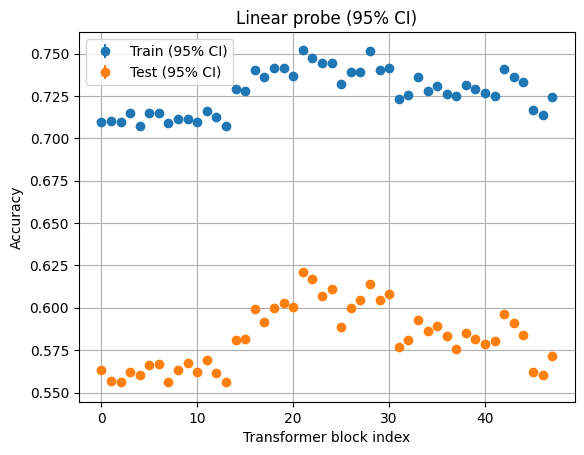

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy import stats

# Organize data by transformer block index
train_data = defaultdict(list)
test_data = defaultdict(list)

for idx, samples in records:
    for train, test in samples:
        train_data[idx].append(train)
        test_data[idx].append(test)

# Compute mean and 95% CI for each block
train_means = []
train_cis = []
test_means = []
test_cis = []
indices = sorted(train_data.keys())

for idx in indices:
    train_vals = np.array(train_data[idx])
    test_vals = np.array(test_data[idx])
    
    n_train = len(train_vals)
    n_test = len(test_vals)
    
    # Mean
    train_mean = np.mean(train_vals)
    test_mean = np.mean(test_vals)
    
    # 95% CI using t-distribution
    train_ci = stats.t.ppf(0.975, n_train-1) * np.std(train_vals, ddof=1) / np.sqrt(n_train)
    test_ci = stats.t.ppf(0.975, n_test-1) * np.std(test_vals, ddof=1) / np.sqrt(n_test)
    
    train_means.append(train_mean)
    train_cis.append(train_ci)
    test_means.append(test_mean)
    test_cis.append(test_ci)

    print(f"layer {idx:02d} | train: {train_mean*100:.2f}%, train: {test_mean*100:.2f}%")

logger.setLevel("INFO")

# Plot with 95% CI error bars
plt.errorbar(indices, train_means, yerr=train_cis, fmt='o', label="Train (95% CI)")
plt.errorbar(indices, test_means, yerr=test_cis, fmt='o', label="Test (95% CI)")
plt.xlabel("Transformer block index")
plt.ylabel("Accuracy")
plt.title("Linear probe (95% CI)")
plt.legend()
plt.grid()
plt.show()